In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/SaeidRostami/Customer_Churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Clean TotalCharges and define target

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("Dataset shape after cleaning:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Target distribution:")
print(df['Churn'].value_counts())

Dataset shape after cleaning: (7032, 21)
Missing values: 0
Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [3]:
features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'InternetService',
    'PaymentMethod',
    'TechSupport',
    'OnlineSecurity',
    'PaperlessBilling',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]

X = df[features]
y = df['Churn']

X_encoded = pd.get_dummies(
    X,
    columns=[
        'Contract',
        'InternetService',
        'PaymentMethod',
        'TechSupport',
        'OnlineSecurity',
        'PaperlessBilling',
        'Partner',
        'Dependents'
    ],
    drop_first=True,
    dtype=int
)

print("Feature shape:", X_encoded.shape)
print("Target shape:", y.shape)

Feature shape: (7032, 18)
Target shape: (7032,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 18)
Testing data: (1407, 18)


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [6]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0]


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8024164889836531

Confusion Matrix:
[[919 114]
 [164 210]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



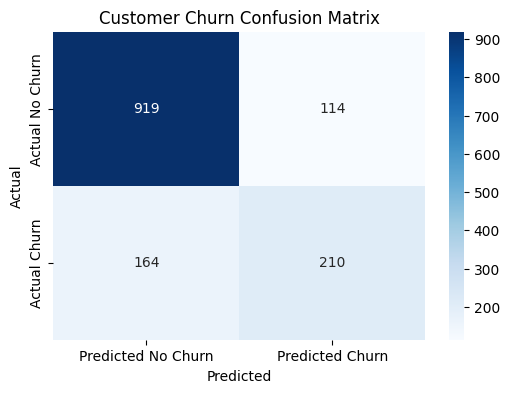

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No Churn', 'Predicted Churn'],
    yticklabels=['Actual No Churn', 'Actual Churn']
)

plt.title("Customer Churn Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nBusiness Impact:")
print("False Positive: Customer predicted to churn, but actually stays.")
print("False Negative: Customer predicted to stay, but actually churns.")

True Negatives : 919
False Positives: 114
False Negatives: 164
True Positives : 210

Business Impact:
False Positive: Customer predicted to churn, but actually stays.
False Negative: Customer predicted to stay, but actually churns.


In [10]:
predictions = X_test.copy()

predictions['Actual Churn'] = y_test.values
predictions['Predicted Churn'] = y_pred

predictions.to_csv(
    "day15_churn_predictions.csv",
    index=False
)

print("Prediction results saved successfully!")
print("File: day15_churn_predictions.csv")
print("Rows:", len(predictions))

Prediction results saved successfully!
File: day15_churn_predictions.csv
Rows: 1407


In [11]:
print("DAY 15 - CUSTOMER CHURN CLASSIFICATION")
print("----------------------------------------")
print("Model: Logistic Regression")
print("Dataset: Telco Customer Churn")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
print("True Negatives:", tn)
print("Prediction file: day15_churn_predictions.csv")

DAY 15 - CUSTOMER CHURN CLASSIFICATION
----------------------------------------
Model: Logistic Regression
Dataset: Telco Customer Churn
Training rows: 5625
Testing rows: 1407
Features: 18
Accuracy: 0.8024
False Positives: 114
False Negatives: 164
True Positives: 210
True Negatives: 919
Prediction file: day15_churn_predictions.csv
